In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


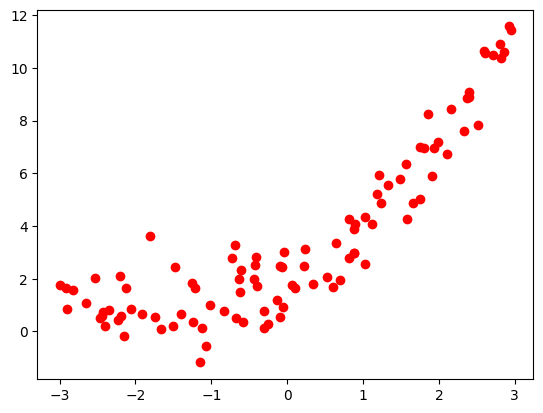

In [4]:
x=6*np.random.rand(100,1)-3
y=0.5 *x**2+1.5*x+2+np.random.randn(100,1)
plt.scatter(x,y,color='red')


In [5]:
from sklearn.model_selection import train_test_split
x_t,x_test,y_t,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [7]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_t,y_t)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 1)",[[1.69]]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[3.41]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,1
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[15.34]


In [9]:
from sklearn.metrics import r2_score
score=r2_score(y_test,regression.predict(x_test))
print(score)

0.5414945916519665


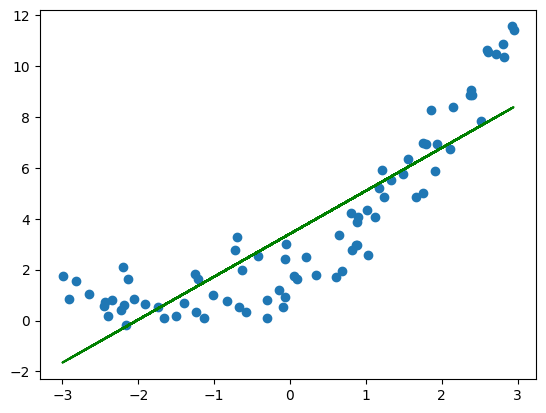

In [11]:
plt.plot(x_t,regression.predict(x_t),color='g')
plt.scatter(x_t,y_t)

In [12]:
#lets apply polynoimal transformation
from sklearn.preprocessing import PolynomialFeatures


In [29]:
poly=PolynomialFeatures(degree=2, include_bias=True)
x_t_p=poly.fit_transform(x_t)
x_testp=poly.transform(x_test)


In [30]:
x_t_p

array([[ 1.00000000e+00,  1.17749642e+00,  1.38649782e+00],
       [ 1.00000000e+00,  2.37543765e+00,  5.64270404e+00],
       [ 1.00000000e+00,  8.82900537e-01,  7.79513358e-01],
       [ 1.00000000e+00,  5.92380163e-02,  3.50914257e-03],
       [ 1.00000000e+00, -2.39681025e+00,  5.74469939e+00],
       [ 1.00000000e+00, -2.43447512e+00,  5.92666911e+00],
       [ 1.00000000e+00, -2.22403331e+00,  4.94632417e+00],
       [ 1.00000000e+00, -4.69238464e-02,  2.20184736e-03],
       [ 1.00000000e+00,  8.19488800e-01,  6.71561893e-01],
       [ 1.00000000e+00, -5.78452840e-01,  3.34607689e-01],
       [ 1.00000000e+00,  1.85298450e+00,  3.43355154e+00],
       [ 1.00000000e+00, -1.24139136e+00,  1.54105250e+00],
       [ 1.00000000e+00,  1.32636967e+00,  1.75925651e+00],
       [ 1.00000000e+00, -2.12894772e+00,  4.53241841e+00],
       [ 1.00000000e+00, -1.74227215e+00,  3.03551223e+00],
       [ 1.00000000e+00,  6.07077553e-01,  3.68543156e-01],
       [ 1.00000000e+00,  1.75090435e+00

In [31]:
from sklearn.linear_model import LinearRegression
regression=LinearRegression()
regression.fit(x_t_p,y_t)
y_pred=regression.predict(x_testp)
from sklearn.metrics import r2_score
score=r2_score(y_test,y_pred)
print(score)

0.7973828885777092


In [32]:
print(regression.coef_)

[[0.         1.65487884 0.53100854]]


In [33]:
print(regression.intercept_)

[1.8432351]


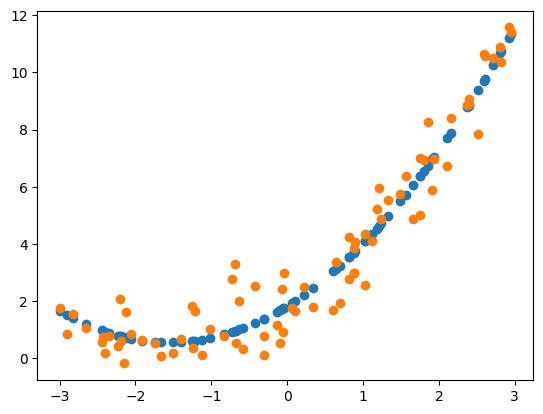

In [34]:
plt.scatter(x_t,regression.predict(x_t_p))
plt.scatter(x_t,y_t)

In [37]:
#prediction of new datset
x_new=np.linspace(-3,3,200).reshape(200,1)
x_new_p=poly.transform(x_new)
x_new_p

array([[ 1.00000000e+00, -3.00000000e+00,  9.00000000e+00],
       [ 1.00000000e+00, -2.96984925e+00,  8.82000455e+00],
       [ 1.00000000e+00, -2.93969849e+00,  8.64182723e+00],
       [ 1.00000000e+00, -2.90954774e+00,  8.46546804e+00],
       [ 1.00000000e+00, -2.87939698e+00,  8.29092700e+00],
       [ 1.00000000e+00, -2.84924623e+00,  8.11820409e+00],
       [ 1.00000000e+00, -2.81909548e+00,  7.94729931e+00],
       [ 1.00000000e+00, -2.78894472e+00,  7.77821267e+00],
       [ 1.00000000e+00, -2.75879397e+00,  7.61094417e+00],
       [ 1.00000000e+00, -2.72864322e+00,  7.44549380e+00],
       [ 1.00000000e+00, -2.69849246e+00,  7.28186157e+00],
       [ 1.00000000e+00, -2.66834171e+00,  7.12004747e+00],
       [ 1.00000000e+00, -2.63819095e+00,  6.96005151e+00],
       [ 1.00000000e+00, -2.60804020e+00,  6.80187369e+00],
       [ 1.00000000e+00, -2.57788945e+00,  6.64551400e+00],
       [ 1.00000000e+00, -2.54773869e+00,  6.49097245e+00],
       [ 1.00000000e+00, -2.51758794e+00

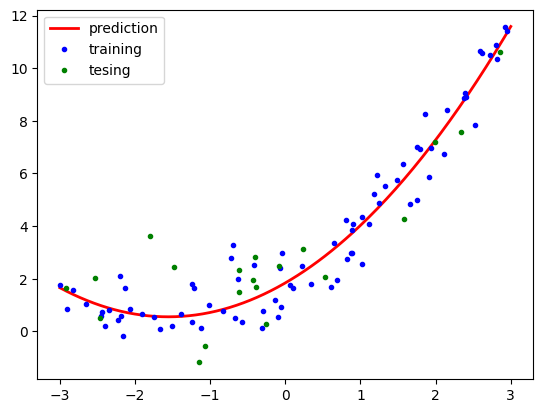

In [39]:
y_new=regression.predict(x_new_p)
plt.plot(x_new,y_new,'r-',linewidth=2,label='prediction')
plt.plot(x_t,y_t,'b.',label='training')
plt.plot(x_test,y_test,'g.',label='tesing')
plt.legend()
plt.show()

PIPELINE 

In [40]:
from sklearn.pipeline import Pipeline


In [43]:
def poly_regression(degree):
    x_new=np.linspace(-3,3,200).reshape(200,1)
    poly_feature=PolynomialFeatures(degree=degree,include_bias=True)
    lin_reg=LinearRegression()
    poly_reg=Pipeline([
        ("poly_features",poly_feature),
        ('lin_reg', lin_reg)
    ])
    poly_reg.fit(x_t,y_t)
    y_pred_new=poly_reg.predict(x_new)
    plt.plot(x_new,y_pred_new,'r',label="degree"+ str(degree),linewidth=2)
    plt.plot(x_t,y_t,'b.',linewidth=2)
    plt.plot(x_test,y_test,'g.',linewidth=2)
    plt.show()


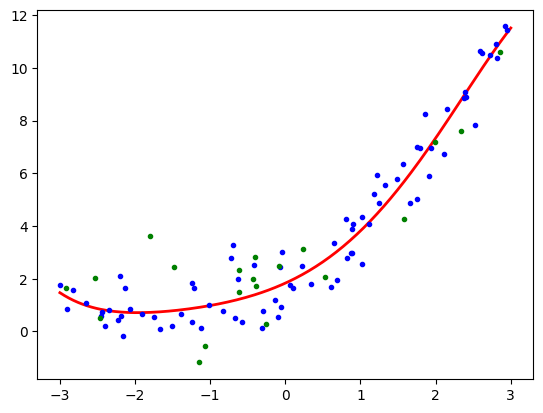

In [44]:
poly_regression(5)